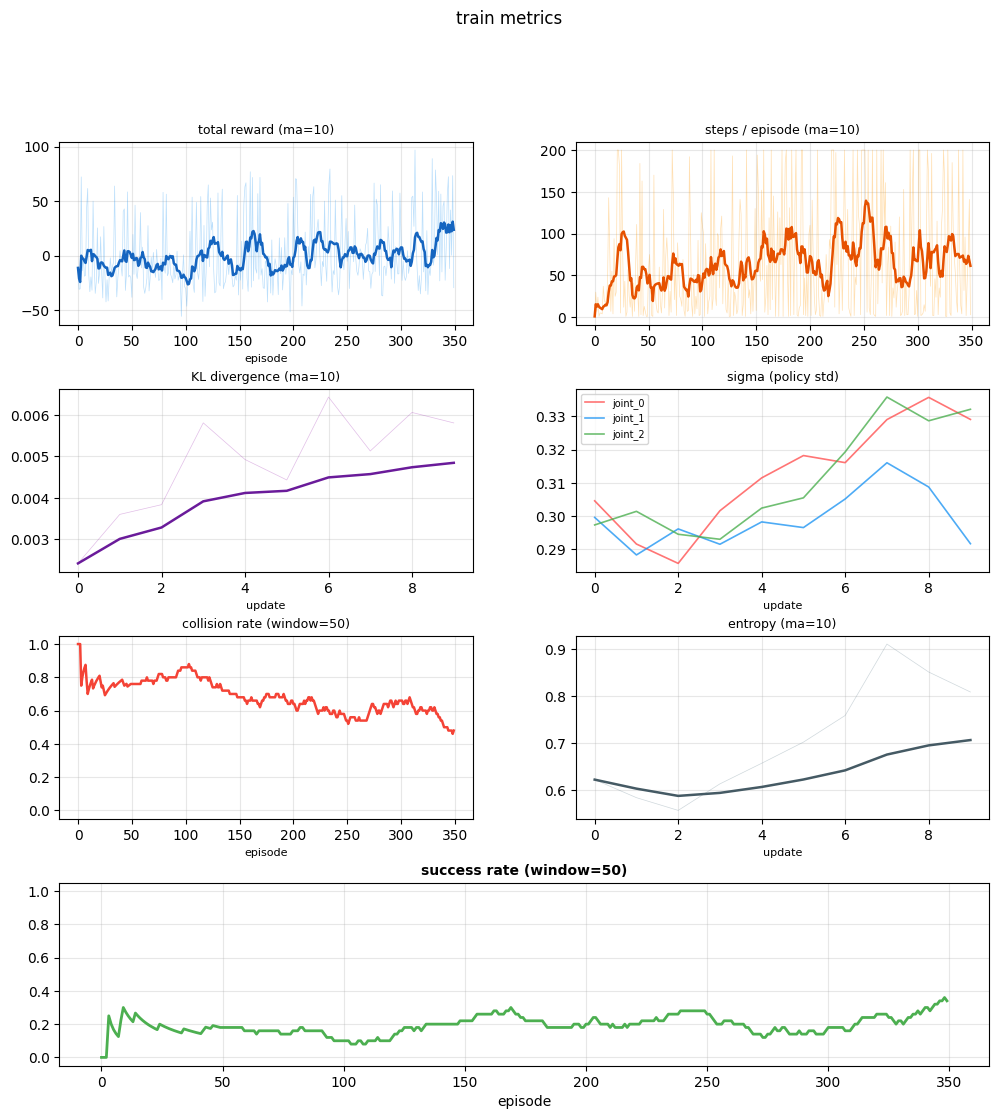

In [ ]:
from reinforce.config import (
    RobotConfig, EnvConfig, RewardConfig, GUIConfig,
    ModelConfig, LidarConfig, ObstacleConfig,
)
from reinforce.runner import Runner, compute_obs_dim
from reinforce.model_ppo import Model

robot_cfg    = RobotConfig()
lidar_cfg    = LidarConfig()
model_cfg    = ModelConfig() 
gui_cfg      = GUIConfig(steps_per_frame_no_sim=2000, plot_update_every=50)

obs_dim = compute_obs_dim(robot_cfg, lidar_cfg)
model   = Model(
    obs_dim=obs_dim,
    act_dim=len(robot_cfg.link_lengths),
    cfg=model_cfg,
    action_limit=robot_cfg.dtheta_max,
    train_episodes=gui_cfg.train_episodes,
)

runner = Runner(
    env_cfg=EnvConfig(),
    reward_cfg=RewardConfig(),
    robot_cfg=robot_cfg,
    lidar_cfg=lidar_cfg,
    obstacle_cfg=ObstacleConfig(),
    gui_cfg=gui_cfg,
    model=model,
)

runner.train()
runner.save_model()